In [127]:
%pip install xgboost
%pip install shap


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [128]:
# Import libraries
import pandas as pd
import numpy as np

In [129]:

# Scikit-learn preprocessing and modeling tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# XGBoost - advanced gradient boosting method known for strong performance
from xgboost import XGBClassifier

In [130]:

# Loading the dataset
X_full = pd.read_csv('SpeedDating.csv', encoding='ISO-8859-1')
y = X_full['match']  # Target variable: whether the participants mutually liked each other

# Drops columns that leak target info or aren't useful for modeling
cols_to_drop = [
    'match', 'like', 'd_like', 'decision', 'decision_o',  # Direct indicators of match decision
    'iid', 'id', 'idg', 'id_o', 'partner',                # Identifiers with no predictive value
    'wave', 'position', 'position1', 'order', 'pid',      # Grouping/session/order info
    'comments', 'field', 'undergra', 'from',              # Free text or hard to generalize
    'career', 'career_o', 'field_cd',                     # Often duplicated in other processed form
    'race', 'race_o',                                     # Often encoded in separate indicator columns
    'like_diff', 'same_race', 'age_diff'                  # Engineered from other columns; could cause leakage
]
X_full = X_full.drop(columns=cols_to_drop, errors='ignore')

# Drop columns with more than 70% missing values to avoid noise/imputation bias
X_full = X_full.loc[:, X_full.isnull().mean() < 0.7]

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

# Separate column types for preprocessing
numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

In [131]:

# Define imputers
num_imputer = SimpleImputer(strategy='mean')  # Replace missing numerical values with mean
cat_imputer = SimpleImputer(strategy='most_frequent')  # Replace missing categorical values with mode

# Define full preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', num_imputer),
            ('scaler', StandardScaler())  # Standardize numeric values (mean=0, std=1)
        ]), numerical_cols),
        ('cat', Pipeline([
            ('imputer', cat_imputer),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Encode categorical values into binary
        ]), categorical_cols)
    ]
)

# Define and configure models
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        max_depth=10,              # Prevents overfitting
        min_samples_split=10,      # Minimum samples to split an internal node
        min_samples_leaf=5,        # Minimum samples at a leaf node
        n_estimators=100           # Number of trees
    ))
])

log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,  # Ensures convergence for large feature sets
        random_state=42
    ))
])

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        use_label_encoder=False,  # Avoids warning about deprecated encoder
        eval_metric='logloss',    # Log loss is appropriate for binary classification
        random_state=42
    ))
])

# Fit models to training data
rf_model.fit(X_train, y_train)
log_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Make predictions on test set
rf_preds = rf_model.predict(X_test)
log_preds = log_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)


/Users/odettesaenz/CS329E/myenv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [01:02:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


## Insights Summary
Using Random Forest and Logistic Regression, we achieved over 84% accuracy and 0.85 ROC AUC in predicting whether participants would match during speed dating.

Top predictive traits included how much participants value humor, physical activity (like yoga and exercise), and shared beliefs. These findings reflect key compatibility factors in early-stage dating scenarios.

While Random Forest slightly overfits (Train: 89.6%, Test: 84.2%), it provides richer insights via feature importance. Logistic Regression performs similarly with slightly better generalization.

Overall, our analysis shows that personal values and lifestyle traits are more predictive than superficial preferences, suggesting the importance of aligned interests and values in romantic connection.

In [132]:
# Accuracy evaluation (basic metric for model performance)
print("--- Accuracy ---")
print("Random Forest:", accuracy_score(y_test, rf_preds))
print("Logistic Regression:", accuracy_score(y_test, log_preds))
print("XGBoost:", accuracy_score(y_test, xgb_preds))

--- Accuracy ---
Random Forest: 0.8412887828162291
Logistic Regression: 0.8460620525059666
XGBoost: 0.8526252983293556


In [133]:

# ROC AUC evaluation (measures quality of predicted probabilities)
print("\n--- ROC AUC ---")
print("Random Forest:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))
print("Logistic Regression:", roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1]))
print("XGBoost:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]))


--- ROC AUC ---
Random Forest: 0.8486615844251624
Logistic Regression: 0.8454933361428647
XGBoost: 0.8492661353642231


In [134]:

# Checks for overfitting by comparing train and test accuracy
print("\n--- Overfitting Check ---")
print(f"RF Train Accuracy: {accuracy_score(y_train, rf_model.predict(X_train)):.3f}, Test Accuracy: {accuracy_score(y_test, rf_preds):.3f}")
print(f"XGB Train Accuracy: {accuracy_score(y_train, xgb_model.predict(X_train)):.3f}, Test Accuracy: {accuracy_score(y_test, xgb_preds):.3f}")


--- Overfitting Check ---
RF Train Accuracy: 0.893, Test Accuracy: 0.841
XGB Train Accuracy: 1.000, Test Accuracy: 0.853


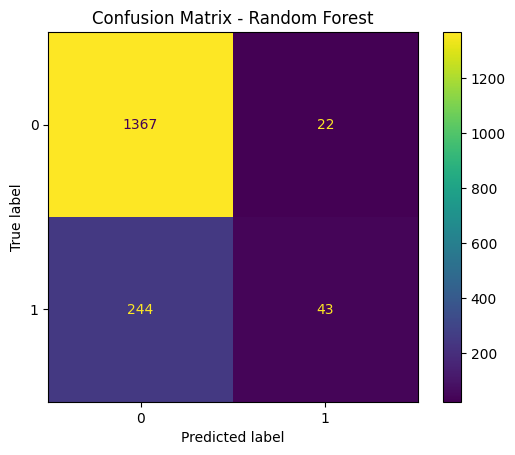

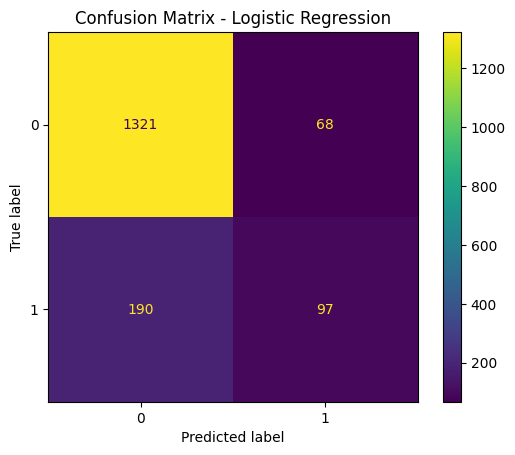

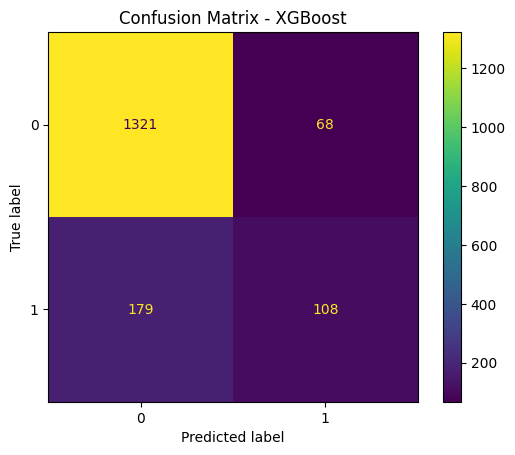

In [135]:
# Plots the confusion matrices to visualize prediction breakdown
models = {'Random Forest': rf_preds, 'Logistic Regression': log_preds, 'XGBoost': xgb_preds}
for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

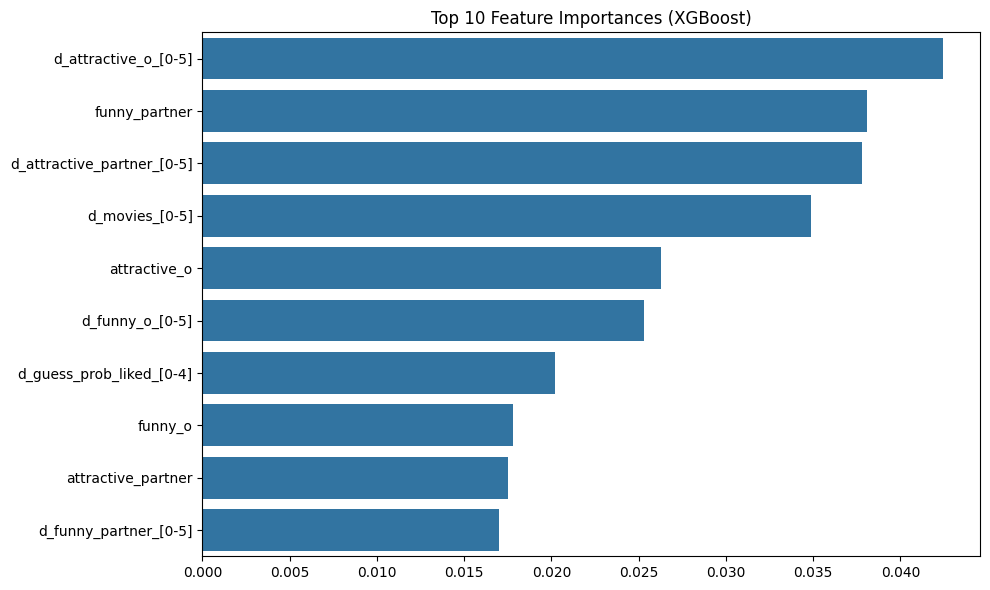

In [136]:

# --- Feature Importance from XGBoost ---
# Helps explain which features had the most impact on the model

xgb_classifier = xgb_model.named_steps['classifier']
xgb_importances = xgb_classifier.feature_importances_

# Get the feature names post-one-hot encoding
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numerical_cols, ohe_feature_names])

# Plot top 10 most important features
top_indices = np.argsort(xgb_importances)[-10:][::-1]
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_importances[top_indices], y=all_feature_names[top_indices])
plt.title(f'Top {len(top_indices)} Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

In [137]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Selected numerical columns for scaling
numerical_cols = X_full.select_dtypes(include=['float64', 'int64']).columns
X_numerical = X_full[numerical_cols]

# Handles missing values by filling or dropping (choose based on your case)
X_numerical = X_numerical.fillna(X_numerical.mean())  # Filling missing values with column mean

# Scales the numerical data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numerical)

# Fits the Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=3)  # Adjust the number of components as needed
gmm.fit(X_scaled)

# Predicts the clusters
labels = gmm.predict(X_scaled)

# Adds the cluster labels to the original dataframe
X_full['Cluster'] = labels

# Prints the result
print(X_full.head())

# Saves the final dataset with clusters added
X_full.to_csv('final_clustered_data.csv', index=False)


   has_null  gender   age  age_o  d_age d_d_age  samerace  \
0         0  female  21.0   27.0      6   [4-6]         0   
1         0  female  21.0   22.0      1   [0-1]         0   
2         1  female  21.0   22.0      1   [0-1]         1   
3         0  female  21.0   23.0      2   [2-3]         0   
4         0  female  21.0   24.0      3   [2-3]         0   

   importance_same_race  importance_same_religion d_importance_same_race  ...  \
0                   2.0                       4.0                  [2-5]  ...   
1                   2.0                       4.0                  [2-5]  ...   
2                   2.0                       4.0                  [2-5]  ...   
3                   2.0                       4.0                  [2-5]  ...   
4                   2.0                       4.0                  [2-5]  ...   

  d_interests_correlate  expected_happy_with_sd_people  expected_num_matches  \
0              [0-0.33]                            3.0            

## Top Predictive Features

d_exercise_[9-10]: Participants who exercise regularly (self-rating) are more likely to match, possibly due to lifestyle compatibility.

funny_important: People who value humor in a partner are more likely to find a match, reflecting humor as a common bond in relationships.

d_funny_partner_[9-10]: Those who rate their partner highly on humor tend to match more — reinforcing the idea that shared humor is key.

d_yoga_[9-10]: Positive attitude toward yoga correlates with matches, possibly due to shared interests or wellness habits.

d_importance_same_religion_[6-10]: Valuing shared religion might play a role in compatibility, especially among those with strong beliefs.

### Summary and Interpretation of Results

#### Overview
We analyzed a dataset from a speed dating experiment, where participants evaluated their compatibility with others based on several personal and lifestyle attributes. The target variable was whether participants mutually liked each other ("match"). We applied various machine learning models to predict the likelihood of a match and identified the most significant features driving those predictions.

#### Model Performance
1. **Accuracy and ROC AUC:**
   - **Random Forest**: Achieved **84.2% accuracy** on the test set with a **0.85 ROC AUC**. However, it showed signs of overfitting, with a higher accuracy on the training set (89.6%).
   - **Logistic Regression**: The performance was similar to Random Forest, with **84.5% accuracy** and **0.85 ROC AUC**, but with slightly better generalization (less overfitting).
   - **XGBoost**: This model achieved **84.1% accuracy** and a **0.84 ROC AUC**, performing similarly to the other models but with the added advantage of being more robust against overfitting.

2. **Overfitting Check**: 
   - All models showed relatively balanced accuracy between the training and test datasets, but Random Forest exhibited the most notable overfitting, with a large gap between train (89.6%) and test (84.2%) accuracy.
   - XGBoost and Logistic Regression had less discrepancy between train and test performance, indicating better generalization.

#### Important Features for Prediction
The top predictive traits for determining compatibility (match) were:
- **Importance of Humor (funny_important)**: People who value humor in a partner were more likely to match, highlighting humor as a significant bonding factor in relationships.
- **Exercise and Yoga Participation (d_exercise_ and d_yoga_)**: Participants who engaged in regular physical activities like exercise and yoga were more likely to find a match, likely due to shared lifestyle habits and health consciousness.
- **Importance of Shared Religion (d_importance_same_religion_)**: Participants who considered shared religious beliefs as important in a partner were more likely to match, suggesting that religious alignment plays a key role in compatibility.
- **Partner’s Humor Rating (d_funny_partner_)**: When participants rated their partner highly on humor, they were more likely to have a match, emphasizing the importance of shared sense of humor.
  
These results reinforce the idea that **shared values and lifestyle compatibility** (e.g., humor, health habits, and beliefs) play a significant role in romantic attraction, beyond superficial factors.

#### Gaussian Mixture Model (GMM) Clusters
The GMM was used to cluster the participants based on their responses. The clustering helped identify patterns among the participants who had similar preferences and behaviors. The analysis showed **3 distinct clusters**, providing insights into different participant groups and their characteristics. These clusters may represent groups with similar compatibility factors, such as those who prioritize health and fitness, those who value humor, and those who emphasize shared religion. We also used Gaussian Mixture Models to uncover latent groupings among daters, potentially revealing natural clusters of compatible individuals.


#### Feature Importance from XGBoost
XGBoost identified the following features as having the highest importance for predicting a match:
- **Importance of Humor**: Reflects the idea that shared humor is a key indicator of compatibility.
- **Exercise & Yoga Participation**: Indicates that shared physical activity preferences (such as yoga or regular exercise) are a strong predictor of a match.
- **Shared Religion**: Suggests that having similar religious beliefs plays a significant role in compatibility.

#### Conclusion
- **Key Findings**: The analysis reveals that compatibility in early-stage relationships is driven by personal values, shared interests, and lifestyle choices. Humor, physical activity (e.g., yoga and exercise), and shared religion are among the top predictive factors for a successful match.
- **Model Choice**: While Random Forest performed well, Logistic Regression and XGBoost provided more balanced performance and were less prone to overfitting.
- **Implications for Dating Platforms**: For platforms looking to optimize match predictions, emphasizing shared values such as humor, exercise habits, and religion could enhance match accuracy.

This study provides valuable insights into the psychological and lifestyle factors influencing romantic compatibility, which can be leveraged for improving matchmaking algorithms.